In [50]:
import kagglehub
import shutil
# path = kagglehub.dataset_download("anninasimon/employee-salary-dataset")

# # Copy the dataset to your Google Drive
# shutil.copytree(
#     path,
#     "/content/drive/MyDrive/AML_MSIS/DataSets/employee-salary-dataset",
#     dirs_exist_ok=True
# )

# path = kagglehub.dataset_download("muhamedumarjamil/student-placement-data-with-cgpa-and-salary")

# # Copy the dataset to your Google Drive
# shutil.copytree(
#     path,
#     "/content/drive/MyDrive/AML_MSIS/DataSets/student-placement",
#     dirs_exist_ok=True
# )
# print("Dataset saved to Google Drive!")

#The above 2 datasets have been imported but have reported to have a
# very low r2 score and was not  good enough for linear regression
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "placement.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tann22u/placement-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


/tmp/ipykernel_4737/2150705320.py:30: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'placement-dataset' dataset.
First 5 records:    cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


(200, 2)

 MAE : 0.23150985393278373

 MSE : 0.08417638361329656

 RMSE : 0.2901316659954521

 R2 Score : 0.7730984312051673


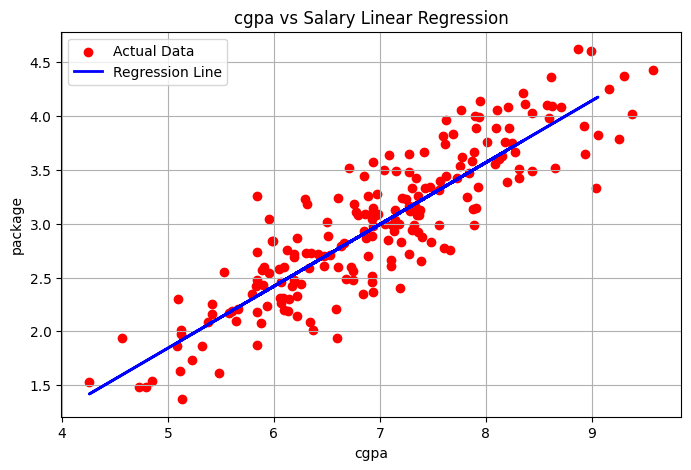

In [49]:
from numpy.random import RandomState
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split


# df = pd.read_csv("/content/drive/MyDrive/AML_MSIS/DataSets/Employee_Salary_Dataset.csv")
# df = pd.read_csv("/content/drive/MyDrive/AML_MSIS/DataSets/Placement.csv")

# df = df.head(800)

print(df.shape)
X = df[['cgpa']]
y = df['package']


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


print("\n MAE :",mean_absolute_error(y_test,y_pred))
print("\n MSE :",mean_squared_error(y_test,y_pred))
print("\n RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("\n R2 Score :",r2_score(y_test,y_pred))



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['cgpa'],
            df['package'],
            color = 'red',
            label = 'Actual Data'
            )
plt.plot(
    X_test['cgpa'],
    y_pred,
    color='blue',
    linewidth=2,
    label='Regression Line'
)
plt.xlabel('cgpa')
plt.ylabel('package')
plt.title('cgpa vs Salary Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

